<a href="https://colab.research.google.com/github/aiyman14/Sch-Mgmt-661/blob/main/MiniProject_Price_Prediction_with_Airbnb_Listing_Data__shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---

## Tutorial 2: Data Preparation and Exploratory Data Analysis (EDA) and Price Prediction (Regression)
**Dataset:** Inside Airbnb – Asheville Listings

---

This tutorial will guide you through the essential steps of data preparation and exploratory data analysis using the **Pandas** and **Seaborn** libraries in Python. You will learn how to:

- Load and explore a real-world dataset  
- Identify and handle missing data  
- Understand the structure and types of variables  
- Prepare the dataset for future modeling

We will be working in **Google Colab**, using an open dataset from **Inside Airbnb**, which provides transparent data on Airbnb listings across cities.


##1. Data Loading and Initial Exploration

In [1]:
# Import required libraries for data analysis and visualization

import pandas as pd              # for data manipulation
import numpy as np               # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns            # for enhanced visualizations

# Set a default aesthetic style for plots
sns.set(style="whitegrid")



In [2]:
# import Airbnb Listing datasets for Asheville

listings_url = 'https://data.insideairbnb.com/united-states/nc/asheville/2024-06-21/data/listings.csv.gz'

# Load the datasets into DataFrames
listings_df = pd.read_csv(listings_url, compression='gzip')



### Exercise 1: Explore the Airbnb Dataset

Use the following commands to get an initial overview of the data:

```python
listings_df.head()     # Display the first few rows  
listings_df.info()     # Explore columns, data types, and missing values  
listings_df.shape      # Shape of the DataFrame (rows, columns)  


#### 🔍 What to Look For:

- **Dataset structure**: What kinds of columns are present? Do they look like numeric, categorical, or text?
- **Important variables**: Can you identify columns that might be useful for analysis, such as `price`, `room_type`, or `number_of_reviews`?
- **Missing data**: Are any columns showing a high number of missing (`null`) values?
- **Data types**: Are the data types appropriate for each column (e.g., numeric for prices)?
- **Size of the dataset**: How many rows and columns does the dataset contain?


In [3]:
# Ex1 a: Display the first 10 rows
listings_df.head(10)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,155305,https://www.airbnb.com/rooms/155305,20240621025915,2024-06-21,city scrape,Cottage! BonPaul + Sharky's Hostel,NaN,"We are within easy walk of pubs, breweries, mu...",https://a0.muscache.com/pictures/8880711/cf38d...,746673,...,4.75,4.92,4.58,NaN,f,8,2,2,4,2.78
1,156805,https://www.airbnb.com/rooms/156805,20240621025915,2024-06-21,city scrape,"Private Room ""Ader"" at BPS Hostel",NaN,"Easy walk to pubs, cafes, bakery, breweries, l...",https://a0.muscache.com/pictures/23447d55-fa7e...,746673,...,4.61,4.84,4.46,NaN,t,8,2,2,4,0.43
2,156926,https://www.airbnb.com/rooms/156926,20240621025915,2024-06-21,city scrape,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...,NaN,https://a0.muscache.com/pictures/5fa7178e-c514...,746673,...,4.77,4.78,4.78,NaN,t,8,2,2,4,2.17
3,197263,https://www.airbnb.com/rooms/197263,20240621025915,2024-06-21,city scrape,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,961396,...,4.93,4.85,4.98,NaN,f,2,1,1,0,0.57
4,209068,https://www.airbnb.com/rooms/209068,20240621025915,2024-06-21,city scrape,Terrace Cottage,NaN,Our beautiful Grove Park Historic District clo...,https://a0.muscache.com/pictures/1829924/9f3bf...,1029919,...,4.98,4.94,4.79,NaN,f,1,1,0,0,0.42
5,246315,https://www.airbnb.com/rooms/246315,20240621025915,2024-06-21,city scrape,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ...",NaN,https://a0.muscache.com/pictures/5908617/cfe79...,1292070,...,4.65,4.67,4.59,NaN,f,3,2,1,0,0.35
6,259576,https://www.airbnb.com/rooms/259576,20240621025915,2024-06-21,city scrape,"Private, Peaceful, and Free Goat Therapy","Privacy, peaceful, sweet comfortable apartment...",NaN,https://a0.muscache.com/pictures/3564e991-a326...,1362726,...,4.99,4.92,4.95,NaN,t,1,1,0,0,5.49
7,314540,https://www.airbnb.com/rooms/314540,20240621025915,2024-06-21,city scrape,Asheville Urban Farmhouse Entire Home 4.6 mi t...,Step back in time to this ethereal Dutch stone...,City vibes with country appeal. Peaceful neigh...,https://a0.muscache.com/pictures/miso/Hosting-...,381660,...,4.96,4.87,4.91,NaN,f,1,1,0,0,0.16
8,427497,https://www.airbnb.com/rooms/427497,20240621025915,2024-06-21,city scrape,Luxurious Mountain Guest Suite Apartment,Escape to our beautifully furnished luxurious ...,The neighborhood is peaceful and quiet. It has...,https://a0.muscache.com/pictures/4980195/acf66...,1909922,...,4.93,4.93,4.89,NaN,t,1,1,0,0,0.33
9,433646,https://www.airbnb.com/rooms/433646,20240621025915,2024-06-21,city scrape,Room in Historic Arts and Craft Home,This beautiful 1925's Art and Crafts home is l...,We are centrally located in the up and coming ...,https://a0.muscache.com/pictures/7235230/d9057...,1931430,...,4.86,4.32,4.51,NaN,f,2,0,2,0,0.77


In [4]:
# Ex1 b: Explore columns, data types, and non-null counts
listings_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3031 entries, 0 to 3030
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3031 non-null   int64  
 1   listing_url                                   3031 non-null   object 
 2   scrape_id                                     3031 non-null   int64  
 3   last_scraped                                  3031 non-null   object 
 4   source                                        3031 non-null   object 
 5   name                                          3031 non-null   object 
 6   description                                   2939 non-null   object 
 7   neighborhood_overview                         2205 non-null   object 
 8   picture_url                                   3031 non-null   object 
 9   host_id                                       3031 non-null   i

In [5]:
# Ex1 c: Display the shape of the DataFrame (rows, columns)
listings_df.shape

(3031, 75)

##2. Data Selection






### Filtering by Host Location

  
In this tutorial, we focus only on hosts located in **Asheville, NC**, so we first need to explore and filter the dataset by host location.

---

### Exercise 2: Explore Unique Host Locations

```python
# Print all unique host locations in the dataset
print(listings_df['host_location'].unique())      # List all location names
print(len(listings_df['host_location'].unique())) # Total number of unique locations
```

### Exercise 3: Filter Listings for Asheville

Our goal is to isolate listings that are located in **Asheville, NC**.  
There are multiple ways to filter the dataset based on the `host_location` column:

```python
# Option 1: Exact match (case-sensitive)
asheville_df = listings_df[listings_df['host_location'] == 'Asheville, NC']

# Option 2: Case-insensitive match using string contains
asheville_df = listings_df[listings_df['host_location'].str.contains('Asheville', case=False, na=False)]


#### 🔍 What to Look For:


- **Location formatting**: Are the city names consistent (e.g., "Asheville, NC" vs. "Asheville")?
- **Missing data**: Are there any `NaN` values in the `host_location` column?
- **Need for data cleaning**: Is the `host_location` column reliable for filtering, or might it require additional cleaning?
- **Subset success**: After filtering, does the new DataFrame (`asheville_df`) contain only Asheville listings from local hosts? What is the shapeof the filtered dataset


In [6]:
# Ex 2: Print all unique host locations in the dataset
print(listings_df['host_location'].unique())      # List all location names
print(len(listings_df['host_location'].unique())) # Total number of unique locations


['Asheville, NC' 'Fort Lauderdale, FL' nan 'Lexington, KY' 'Fletcher, NC'
 'Evanston, IL' 'Winston-Salem, NC' 'Sebring, FL' 'Austin, TX'
 'Chicago, IL' 'Weaverville, NC' 'North Carolina, United States'
 'Cartersville, GA' 'Newland, NC' 'Arden, NC' 'Candler, NC'
 'Mount Dora, FL' 'Savannah, GA' 'San Diego, CA' 'Miami, FL'
 'Wilmington, NC' 'Flat Rock, NC' 'Barnardsville, NC' 'Fayetteville, NC'
 'Lido Beach, NY' 'Charleston, SC' 'Laguna Beach, CA'
 'Peterborough, Canada' 'United States' 'Brevard, NC' 'Atlanta, GA'
 'Columbia, MD' 'Rocky Mount, NC' 'Woodfin, NC' 'Charlotte, NC'
 'Old Fort, NC' 'Swannanoa, NC' 'Floyds Knobs, IN' 'Saint Petersburg, FL'
 'Arvada, CO' 'Santa Fe, NM' 'Raleigh, NC' 'Mobile, AL' 'Sarasota, FL'
 'New York, United States' 'Boston, MA' 'San Francisco, CA'
 'Vitorino dos Piães, Portugal' 'Johnson City, TN' 'Roswell, GA'
 'Denver, CO' 'Myrtle Beach, SC' 'DeLand, FL' 'Hendersonville, NC'
 'Indianapolis, IN' 'Los Angeles, CA' 'Hemphill, TX' 'Pittsboro, NC'
 'Wake Fores

In [7]:
# Ex 3: Filter Listings for Asheville
asheville_df = listings_df[listings_df['host_location'] == 'Asheville, NC']


In [8]:
# Shape of the filtered dataset
asheville_df.shape

(2003, 75)

### Subset by Columns: Selecting Relevant Features

Now that we’ve filtered Asheville listings from local hosts, let’s simplify it further by selecting a smaller set of **useful columns** for analysis.

We’ll keep:
- **Numerical columns**: e.g., `price`, `bathrooms`,`bedrooms`, `number_of_reviews`, `latitude`, `longitude`
- **Categorical columns**: e.g., `room_type`, `host_identity_verified`, `host_is_superhost`

---

### 🧪 Exercise 4: Create a Subset of Columns

```python
# Define the columns we want to keep
selected_columns = [
    'price', 'bathrooms','bedrooms', 'number_of_reviews', 'latitude',
    'longitude', 'room_type', 'host_identity_verified', 'host_is_superhost'
]

# Create a new DataFrame with only the selected columns
asheville_df = asheville_df[selected_columns]

# Preview the first few rows of the subset
asheville_df.head()


#### 🔍 What to Look For:

- **Missing values**: Do any columns like `bathrooms`, `bedrooms`, or `number_of_reviews` have missing entries?
- **Inconsistent formats**: Is the `price` column stored as a string or object (e.g., with `$`) instead of a numeric type?
- **Data types**: Are numeric-looking columns like `bathrooms`, `bedrooms`, and `price` actually of the correct data type?
- **Binary columns**: Are values in `host_is_superhost` and `host_identity_verified` stored as `'t'`/`'f'`? Would it be better to convert them to `1`/`0`?
- **Categorical columns**: Is `room_type` ready for modeling, or does it need to be one-hot encoded?
- **Geolocation columns**: Are `latitude` and `longitude` necessary for your analysis, or could they be dropped or used later for mapping?

These observations will guide how you clean, transform, and prepare your data in the next step: **Data Pre-processing**.



In [9]:
#Ex 4:  Define the columns we want to keep and create a new dataframe with the selected columns

## Make sure you have all the columns need for the mini-project

selected_columns = [
    'price', 'bathrooms','bedrooms', 'number_of_reviews', 'latitude',
    'longitude', 'room_type', 'host_identity_verified', 'host_is_superhost', 'accommodates', 'review_scores_rating'
]

asheville_df = asheville_df[selected_columns]

In [10]:
## let's count number of amenities



In [11]:
# Preview the first few rows of the new dataframe
asheville_df.head()

,price,bathrooms,bedrooms,number_of_reviews,latitude,longitude,room_type,host_identity_verified,host_is_superhost,accommodates,review_scores_rating
0,$99.00,1.0,1.0,437,35.57864,-82.59578,Entire home/apt,t,t,2,4.61
1,$66.00,2.5,1.0,67,35.57864,-82.59578,Private room,t,t,2,4.52
2,$26.00,2.5,1.0,339,35.57864,-82.59578,Shared room,t,t,1,4.70
3,$49.00,1.0,1.0,82,35.57735,-82.63804,Private room,t,t,2,4.95
4,$100.00,1.0,1.0,65,35.61736,-82.55074,Entire home/apt,t,t,4,4.89


##3. Data Pre Processing
**(Handling missing values, Correcting Data Types, Data Transformation)**

### Exercise 5: Handling Missing Values

Missing data is common in real-world datasets. Before modeling or analysis, we need to decide how to handle it in a way that makes sense for the variable type and purpose.

---

### 5.1: Check for Missing Values

```python
# Count missing values in each column
asheville_df.isnull().sum()
```
---
### 5.2: Dropping Columns or Rows with Missing Values

Since we'll use price as the target variable for a prediction model in the next unit, let's not impute missing price values. Imputing the target could distort model training. Let's drop the records with missing price values. Then we can check the dataframe again for the missing values

```python
# Drop rows where the target variable (price) is missing
asheville_df = asheville_df.dropna(subset=['price'])

# Count missing values in each column
asheville_df.isnull().sum()
```

---


### 5.3: Choosing an Imputation Strategy

There are different ways to fill in missing values:

- **Mean Imputation**: Uses the average value (best for normally distributed data).
- **Median Imputation**: Uses the middle value (more robust to outliers and skewed data).
- **Mode Imputation**: Uses the most frequent value (best for categorical data).

```python

# Below are examples. Select one appropriate strategy per feature, not all at once.

# Impute 'bedrooms' using median
asheville_df['bedrooms'] = asheville_df['bedrooms'].fillna(asheville_df['bedrooms'].median())

# Impute 'bathrooms' using mean
asheville_df['bathrooms'] = asheville_df['bathrooms'].fillna(asheville_df['bathrooms'].mean())

# Impute 'host_is_superhost' using mode
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].fillna(
    asheville_df['host_is_superhost'].mode()[0]
)
```





#### 🔍 What to Look For:

- **Which columns had missing values originally?**  

- **Did we drop rows only where `price` was missing?**  

- **Did missing values remain in other columns after dropping rows?**  

- **Were appropriate imputation strategies used per column?**  

- **Are all missing values now handled?**  

> Tip: Now that missing values are handled, inspect your dataset using .dtypes to verify column types and .describe() to explore statistical properties of numeric columns. This helps catch formatting or conversion issues before the next step

```python
# check data types
asheville_df.dtypes

# generate descriptive statistics
asheville_df.describe()

```


In [12]:
# 5.1: Check for missing values in each column
asheville_df.isnull().sum()

,0
price,100
bathrooms,100
bedrooms,13
number_of_reviews,0
latitude,0
longitude,0
room_type,0
host_identity_verified,0
host_is_superhost,28
accommodates,0


In [13]:
# 5.2: Drop rows where the target variable (price) is missing and then re-check for missing values
asheville_df = asheville_df.dropna(subset=['price'])
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
latitude,0
longitude,0
room_type,0
host_identity_verified,0
host_is_superhost,28
accommodates,0


In [14]:
# 5.3: Use one of the imputation methods to impute missing values, if there are any missing values after dropping records in step 2
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].fillna(
    asheville_df['host_is_superhost'].mode()[0]
)
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
latitude,0
longitude,0
room_type,0
host_identity_verified,0
host_is_superhost,0
accommodates,0


In [15]:
# review score rating

#For review_scores_rating, replace missing values with 0 (indicating no reviews). Create a dummy variable (has_review_scores) to indicate whether a listing has a review:
#Set has_review_scores = 1 if review_scores_rating > 0.
#Set has_review_scores = 0 if review_scores_rating == 0 (no reviews).

asheville_df['review_scores_rating'] = asheville_df['review_scores_rating'].fillna(0)
asheville_df['has_review_scores'] = (asheville_df['review_scores_rating'] > 0).astype(int)





In [16]:
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
latitude,0
longitude,0
room_type,0
host_identity_verified,0
host_is_superhost,0
accommodates,0


In [17]:
# check data types
asheville_df.dtypes

,0
price,object
bathrooms,float64
bedrooms,float64
number_of_reviews,int64
latitude,float64
longitude,float64
room_type,object
host_identity_verified,object
host_is_superhost,object
accommodates,int64


In [18]:
# generate descriptive statistics
asheville_df.describe()

,bathrooms,bedrooms,number_of_reviews,latitude,longitude,accommodates,review_scores_rating,has_review_scores
count,1903.00000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000
mean,1.53258,1.800315,131.829743,35.581414,-82.557001,4.388334,4.628455,0.943248
std,0.89542,1.252992,160.772908,0.041928,0.047012,2.872146,1.141613,0.231430
min,0.00000,0.000000,0.000000,35.426930,-82.670727,1.000000,0.000000,0.000000
25%,1.00000,1.000000,20.000000,35.568280,-82.591448,2.000000,4.850000,1.000000
50%,1.00000,1.000000,74.000000,35.587680,-82.556170,4.000000,4.940000,1.000000
75%,2.00000,2.000000,180.000000,35.605030,-82.524005,6.000000,4.980000,1.000000
max,9.00000,12.000000,1333.000000,35.654710,-82.460210,16.000000,5.000000,1.000000


### Exercise 6: Fixing Data Types and Encoding Columns

Now that we’ve handled missing values, let’s make sure our dataset has the correct data types and is ready for modeling. We’ll fix any incorrectly stored data types and encode categorical or boolean fields.

---

### 6.1: Identify Incorrect Data Types

We already checked `.dtypes` and `.describe()` in the previous exercise. Let’s now review what needs fixing:

- The `price` column is stored as `object` instead of numeric.
- Boolean-like columns (`host_identity_verified`, `host_is_superhost`) use `'t'` and `'f'` strings.
- The `room_type` column is categorical and may need encoding for machine learning.

---

### 6.2: Convert `price` to Numeric

```python
# Remove $ and convert to float
asheville_df['price'] = asheville_df['price'].replace('[\$,]', '', regex=True).astype(float)
```

---

### 6.3: Convert Boolean-like Columns

```python
# Convert 't'/'f' to 1/0
asheville_df['host_identity_verified'] = asheville_df['host_identity_verified'].map({'t': 1, 'f': 0})
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].map({'t': 1, 'f': 0})
```
---

### 6.4: Encode Categorical Column

```python
# One-hot encode 'room_type'
room_type_dummies = pd.get_dummies(asheville_df['room_type'], prefix='room_type', drop_first=True)
room_type_dummies = room_type_dummies.astype(int)

# Add new columns to the DataFrame
asheville_df = pd.concat([asheville_df, room_type_dummies], axis=1)

# Optional: Drop the original categorical column if you want
# asheville_df.drop('room_type', axis=1, inplace=True)
```



### 🔍 What to Look For:

- **Was the `price` column successfully converted to a numeric type?**  

- **Do the boolean columns now contain 1s and 0s instead of strings?**  

- **Did one-hot encoding work as expected?**  


> Use `.dtypes` to confirm column types and `.head()` to visually inspect the first few rows.


In [19]:
# 6.2: Convert price to Numeric
asheville_df['price'] = asheville_df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [20]:
# 6.3: Convert Boolean-like Columns
asheville_df['host_identity_verified'] = asheville_df['host_identity_verified'].map({'t': 1, 'f': 0})
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].map({'t': 1, 'f': 0})

In [21]:
# 6.4: Encode Categorical Column

room_type_dummies = pd.get_dummies(asheville_df['room_type'], prefix='room_type', drop_first=True)
room_type_dummies = room_type_dummies.astype(int)

# Add new columns to the DataFrame
asheville_df = pd.concat([asheville_df, room_type_dummies], axis=1)
asheville_df.drop('room_type', axis=1, inplace=True)

asheville_df.head()

,price,bathrooms,bedrooms,number_of_reviews,latitude,longitude,host_identity_verified,host_is_superhost,accommodates,review_scores_rating,has_review_scores,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,99.0,1.0,1.0,437,35.57864,-82.59578,1,1,2,4.61,1,0,0,0
1,66.0,2.5,1.0,67,35.57864,-82.59578,1,1,2,4.52,1,0,1,0
2,26.0,2.5,1.0,339,35.57864,-82.59578,1,1,1,4.70,1,0,0,1
3,49.0,1.0,1.0,82,35.57735,-82.63804,1,1,2,4.95,1,0,1,0
4,100.0,1.0,1.0,65,35.61736,-82.55074,1,1,4,4.89,1,0,0,0


##4. Exploratory Data Analysis



###  Exercise 7: Exploratory Data Analysis (EDA)
Now that our dataset is cleaned and properly formatted, we can explore its structure and relationships using visual and statistical techniques.

---

## 7.1: Descriptive Statistics

Use `.describe()` to get a statistical summary of numeric features.

```python
asheville_df.describe()
```
---
## 7.2 : Histrograms of Distributions
Visualize distributions of numerical variables like price, bedrooms, bathrooms, and number_of_reviews.

```python
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'number_of_reviews']
asheville_df[numeric_cols].hist(bins=30, figsize=(10,8))
plt.tight_layout()
plt.show()
```
## 7.3: Pair Plot
Understand relationships and potential clusters in the data..

```python
sns.pairplot(asheville_df[numeric_cols])
plt.show()
```

## 7.4: Correlation Matrix
See how variables relate to each other. Useful for feature selection and multicollinearity detection.

```python
corr = asheville_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
```




### 7.5: Handling Outliers

e.g., As you may have observed from the earlier descriptive statistics and distribution plots, the `price` variable is highly skewed.

Most listings fall within a reasonable range, but a small number have unusually high prices. These outliers can distort visualizations and affect the performance of models later on.

To address this, we’ll use the **99th percentile rule** to filter out the top 1% of extreme values — a common practice when working with skewed real-world data.

```python
# Visualize the original price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (Before Removing Top 1%)")
plt.xlabel("Price")
plt.show()
```

```python
# Remove top 1% of extreme price values
price_cap = asheville_df['price'].quantile(0.99)
asheville_df = asheville_df[asheville_df['price'] <= price_cap]
```
```python
# Visualize the cleaned price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (After Removing Top 1%)")
plt.xlabel("Price")
plt.show()
```


### 7.6: Geospatial Plot

Visualize the geographic distribution of listings using latitude and longitude. Color can be used to represent listing price or categories.

We create **price buckets** to group listings into four categories:

- Less than $100  
- $100–$200  
- $200–$300  
- Greater than $300  

Using `plotly.express.scatter_mapbox`, we plot an **interactive map** that lets us:

- Zoom and pan around the city  
- Hover over listings to view price, bedroom, and bathroom details  
- Identify potential geographic pricing patterns (e.g., higher prices in city center vs outskirts)

```python
import plotly.express as px

# Create price buckets
asheville_df['price_range'] = pd.cut(
    asheville_df['price'],
    bins=[0, 100, 200, 300, asheville_df['price'].max()],
    labels=['< $100', '$100–$200', '$200–$300', '>$300']
)

# Plot the interactive map
fig = px.scatter_mapbox(
    asheville_df,
    lat='latitude',
    lon='longitude',
    color='price_range',
    hover_data=['price', 'bedrooms', 'bathrooms'],
    zoom=10,
    mapbox_style="open-street-map",
    title="Airbnb Listings in Asheville by Price Range"
)

fig.show()
```


🔍 What to Look For:

Use this section to uncover patterns, spot outliers, and understand relationships between variables. Key things to explore:

- **Are the numeric variables (like price, bedrooms, bathrooms) distributed normally or skewed?**

- **Are there any correlations between variables?**

- **Are there any surprising or extreme values (outliers)?**

- **Are there geographic patterns in pricing?**
  - Use the geospatial plot to spot high-price clusters or neighborhoods with dense listings.

Tip: EDA insights guide feature selection and transformation decisions before modeling. Take notes on variables that might need normalization, binning, winzorizing, or removal.


In [22]:
# 7.1: Descriptive Statistics

asheville_df.describe()

,price,bathrooms,bedrooms,number_of_reviews,latitude,longitude,host_identity_verified,host_is_superhost,accommodates,review_scores_rating,has_review_scores,room_type_Hotel room,room_type_Private room,room_type_Shared room
count,1903.000000,1903.00000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000,1903.000000
mean,174.972675,1.53258,1.800315,131.829743,35.581414,-82.557001,0.890699,0.770363,4.388334,4.628455,0.943248,0.000525,0.118760,0.003678
std,192.789281,0.89542,1.252992,160.772908,0.041928,0.047012,0.312099,0.420710,2.872146,1.141613,0.231430,0.022923,0.323591,0.060554
min,11.000000,0.00000,0.000000,0.000000,35.426930,-82.670727,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,94.000000,1.00000,1.000000,20.000000,35.568280,-82.591448,1.000000,1.000000,2.000000,4.850000,1.000000,0.000000,0.000000,0.000000
50%,128.000000,1.00000,1.000000,74.000000,35.587680,-82.556170,1.000000,1.000000,4.000000,4.940000,1.000000,0.000000,0.000000,0.000000
75%,199.500000,2.00000,2.000000,180.000000,35.605030,-82.524005,1.000000,1.000000,6.000000,4.980000,1.000000,0.000000,0.000000,0.000000
max,5520.000000,9.00000,12.000000,1333.000000,35.654710,-82.460210,1.000000,1.000000,16.000000,5.000000,1.000000,1.000000,1.000000,1.000000


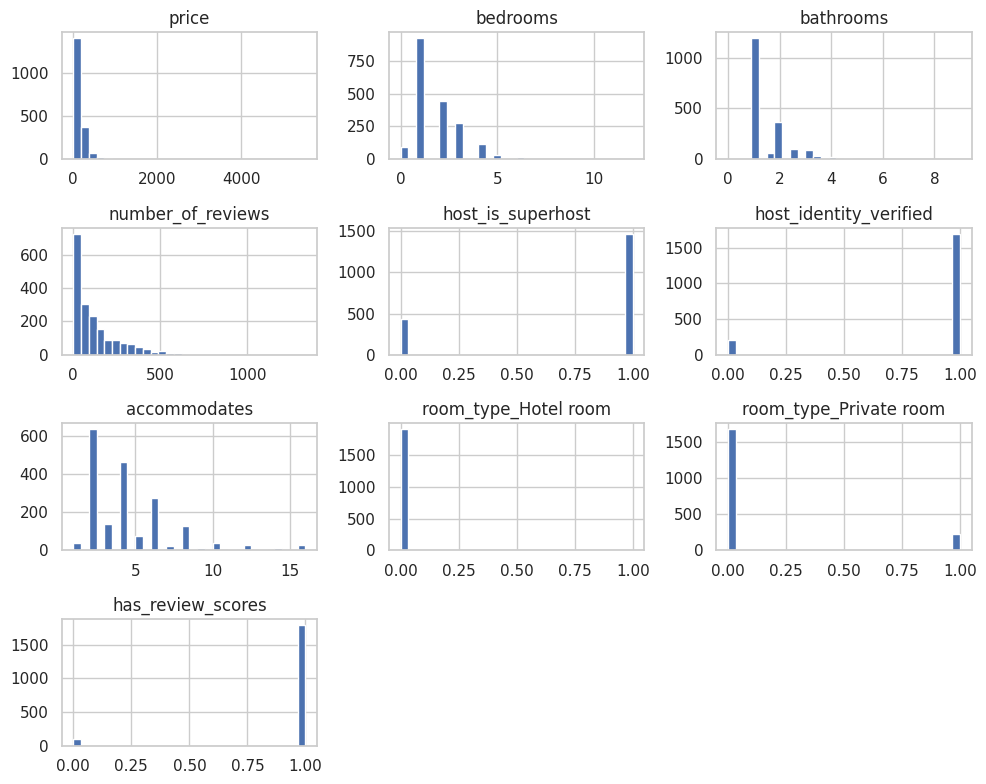

In [23]:
# 7.2: Histrograms of Distributions

# update numerical cols list
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'number_of_reviews', 'host_is_superhost', 'host_identity_verified', 'accommodates', 'room_type_Hotel room', 'room_type_Private room', 'has_review_scores'
            ]
asheville_df[numeric_cols].hist(bins=30, figsize=(10,8))
plt.tight_layout()
plt.show()

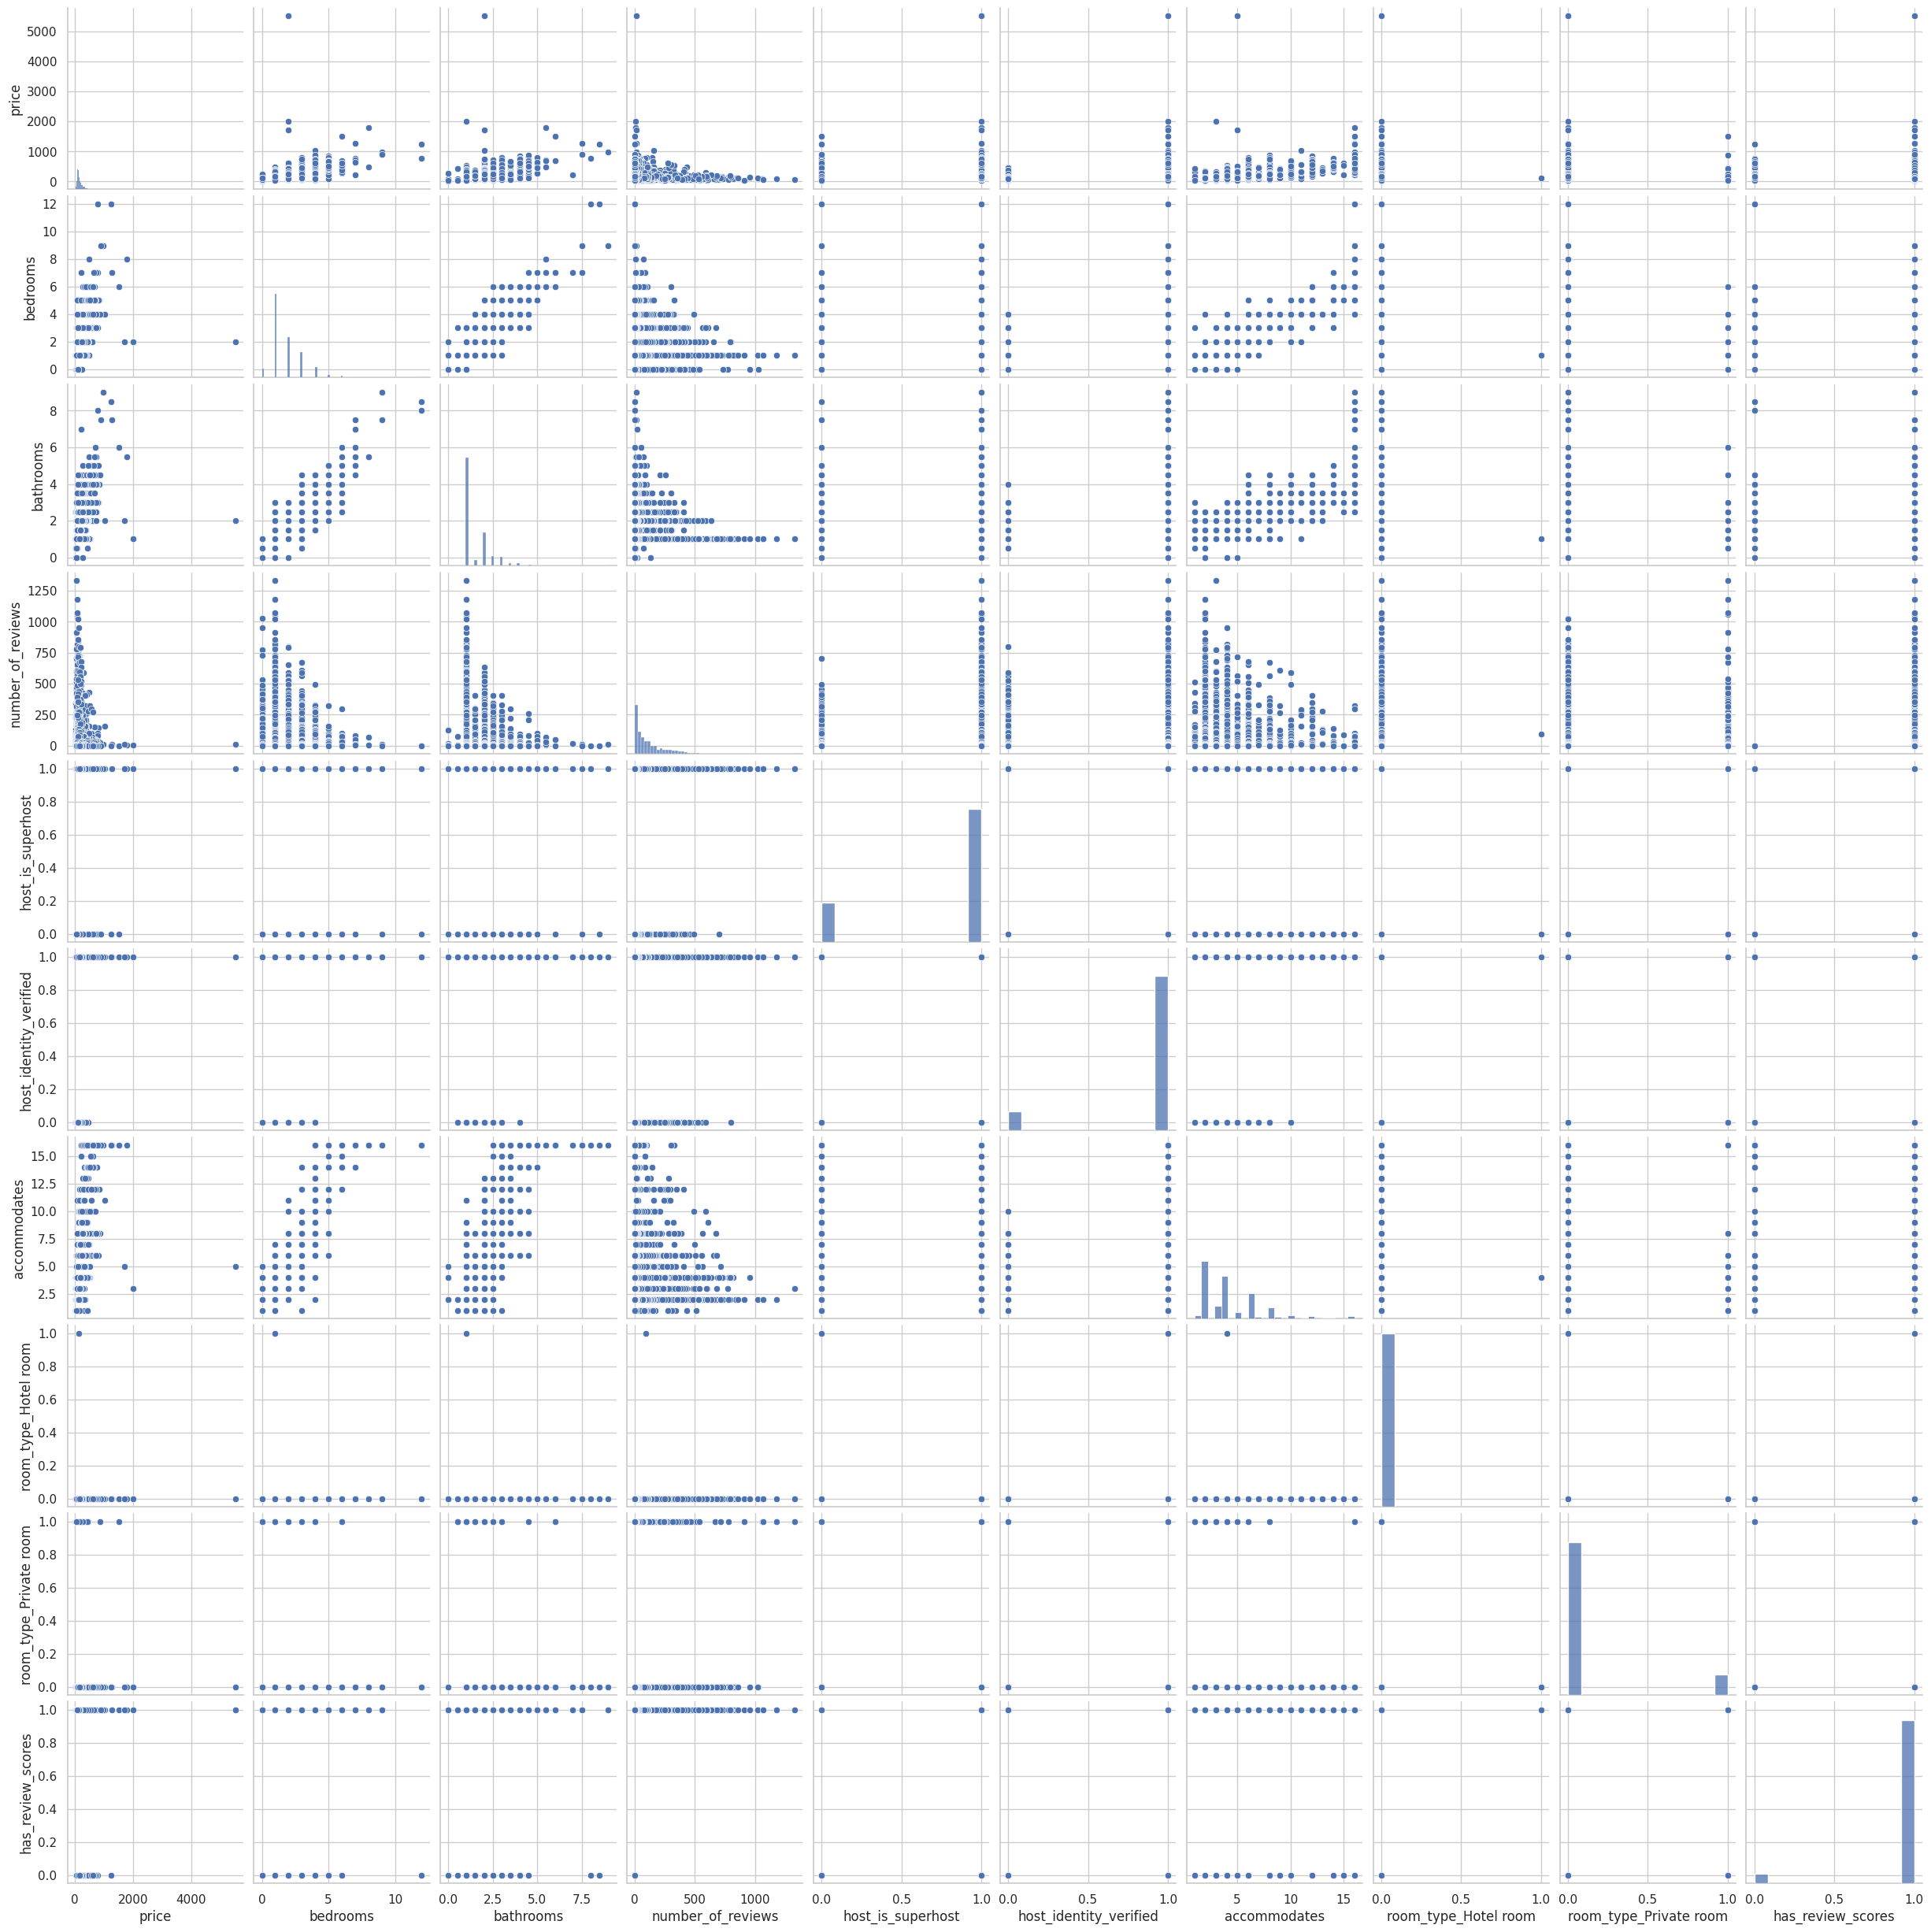

In [24]:
# 7.3: Pair Plot
sns.pairplot(asheville_df[numeric_cols])
plt.show()

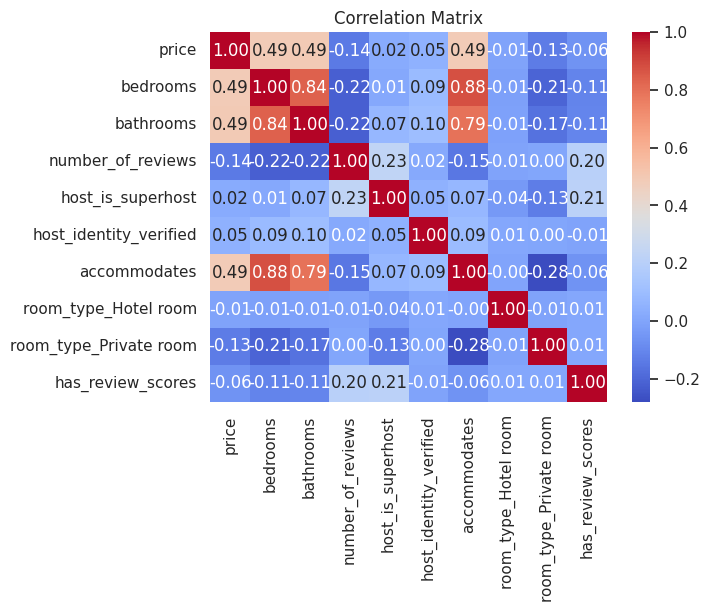

In [25]:
corr =  asheville_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

 7.5: Hadling price outliers

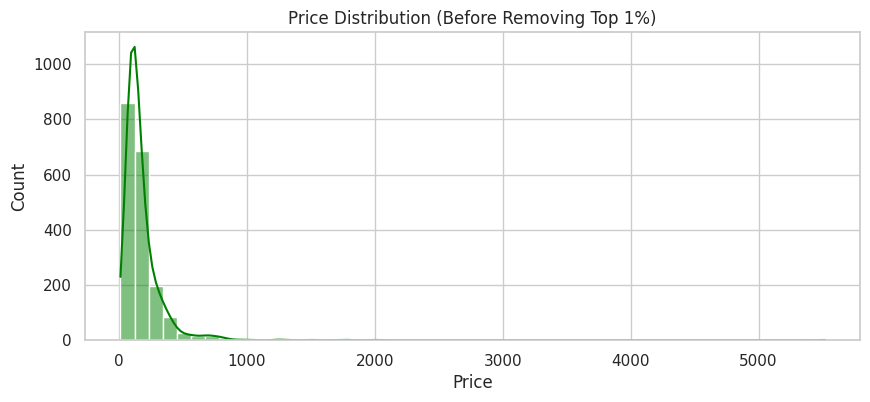

In [26]:
# Visualize the original price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (Before Removing Top 1%)")
plt.xlabel("Price")
plt.show()

In [27]:
# Remove top 1% of extreme price values
price_cap = asheville_df['price'].quantile(0.99)
asheville_df = asheville_df[asheville_df['price'] <= price_cap]


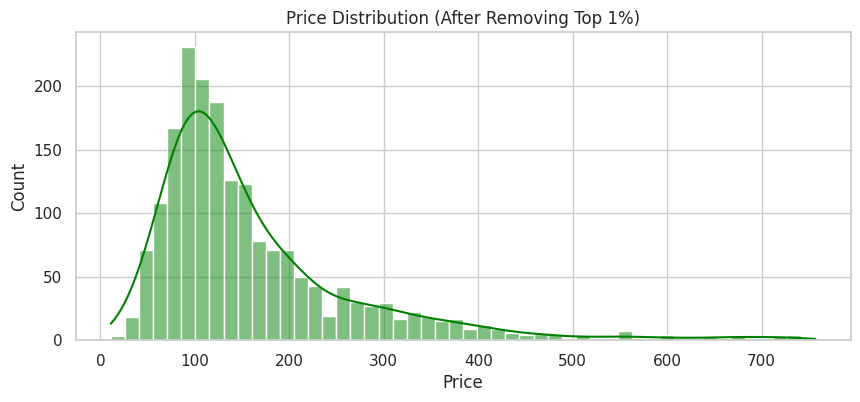

In [28]:
# Visualize the cleaned price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (After Removing Top 1%)")
plt.xlabel("Price")
plt.show()

In [29]:
# 7.6: Geospatial Plot

import plotly.express as px

# Create price buckets
asheville_df['price_range'] = pd.cut(
    asheville_df['price'],
    bins=[0, 100, 200, 300, asheville_df['price'].max()],
    labels=['< $100', '$100–$200', '$200–$300', '>$300']
)

# Plot the interactive map
fig = px.scatter_mapbox(
    asheville_df,
    lat='latitude',
    lon='longitude',
    color='price_range',
    hover_data=['price', 'bedrooms', 'bathrooms'],
    zoom=10,
    mapbox_style="open-street-map",
    title="Airbnb Listings in Asheville by Price Range"
)

fig.show()

##5. Prepare for Modeling (Normalize and Split Data)

In this step, we prepare our dataset for training a neural network using Keras:

- **Feature Selection**: We select a subset of relevant numeric features for predicting listing price, including `bedrooms`, `bathrooms`, `number_of_reviews`, and so on.

- **Train-Test Split**: The dataset is split into training and testing sets using an 80/20 split, ensuring consistent results with `random_state=42`.

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

- **Normalization with Keras Layer**: Instead of using `StandardScaler` from scikit-learn, we utilize Keras’s built-in `Normalization` layer. This approach is fully integrated into the model pipeline and ensures that normalization is learned from the training data only.

```python
norm = Normalization()
norm.adapt(X_train.values)  # Learns mean and variance from training data


In [30]:
# Imports required libraries for pre-processing and modeling

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization, Input
from sklearn.model_selection import train_test_split

# Selecting  features relevant to model_a (base_model)

features = ['bedrooms', 'bathrooms', 'number_of_reviews', 'host_is_superhost', 'host_identity_verified', 'accommodates', 'room_type_Hotel room', 'room_type_Private room','review_scores_rating', 'has_review_scores']
target = 'price'


# Define X and y
X = asheville_df[features]
y = asheville_df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and Adapt Normalization Layer
norm_layer = Normalization()
norm_layer.adapt(X_train.values)



##6. Build, Compile, and Train the Neural Network

**Create a simple Sequential model with:**

* An Input layer that defines the shape of the input features

* A Normalization layer that scales inputs based on training data

* One Dense (fully connected) hidden layer with 64 nodes and ReLU activation

* A final Dense layer with 1 output for price prediction (regression)


**Compile:**

* Loss Function: Mean Squared Error ('mse')

* Optimizer: adam

* Metric: Mean Absolute Error ('mae') for interpretability

**Training:**

* Use 20% of the training data for validation

* Train for 50 epochs



In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function to return evaluation scores

def eval_on_test(m, X_te, y_te):
    y_pred = m.predict(X_te, verbose=0).flatten()
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    return mae, rmse, r2

In [32]:
## Model_a

# Build the Sequential Model
model_a = Sequential([
    Input(shape=(X_train.shape[1],)),
    norm_layer,
    Dense(64, activation='relu'),
    Dense(1)  # Regression output
])

# Compile the Model
model_a.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the Model
hist_a = model_a.fit(
    X_train, y_train,
    validation_split=0.2,  # 20% of training data used for validation
    epochs=70,
    verbose=1
)

mae_a, rmse_a, r2_a = eval_on_test(model_a, X_test, y_test)


Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 37848.2891 - mae: 160.5177 - val_loss: 40393.1641 - val_mae: 164.6820
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37460.1875 - mae: 159.4173 - val_loss: 39919.5391 - val_mae: 163.4736
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36952.3750 - mae: 158.0497 - val_loss: 39277.1797 - val_mae: 161.8995
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36271.9531 - mae: 156.2786 - val_loss: 38430.7383 - val_mae: 159.8631
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35400.0781 - mae: 154.0031 - val_loss: 37378.2734 - val_mae: 157.3122
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 34340.1094 - mae: 151.2052 - val_loss: 36095.1992 - val_mae: 154.1880
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 33076.9023 - mae: 147.8535 - val_loss: 34629.8789 - val_mae: 150.5103
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31646.4121 - mae: 143.9249 - val_loss: 32925.9

In [33]:
# Model _b

# Build model_b


# Compile model_b


# Train model_b

# model_b evaluation scores




In [34]:
# Model c

# 1) Build enhanced feature set
#feature_enh = features + [ '...', '...'	]
#X_enh = asheville_df[feature_enh]

# 2) Use the SAME train/test rows as your baseline split (fair comparison)
#X_train_enh = X_enh.loc[X_train.index]
#X_test_enh  = X_enh.loc[X_test.index]

# 3) Normalization for enhanced feature matrix
#norm_layer_enh = Normalization()
#norm_layer_enh.adapt(X_train_enh.values)

In [35]:
# Model_c
from tensorflow.keras.callbacks import EarlyStopping

# Build model_c


# Compile model_c

# Add EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # stop if no improvement for 8 epochs
    restore_best_weights=True
)

# train model_c with early stopping


# model_c evaluation scores

In [36]:
# these helpe functions will plots training and validation plots


import matplotlib.pyplot as plt

def plot_training_curves(history, model_name="Model"):
    """
    Plots training vs validation MAE and MSE curves for a Keras model history.

    Parameters:
    - history: History object from model.fit()
    - model_name: str, name of the model (for titles)
    """
    # --- Plot MAE ---
    plt.figure(figsize=(6,4))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE (Price)')
    plt.title(f'{model_name}: Training vs Validation MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot Loss (MSE) ---
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.title(f'{model_name}: Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()



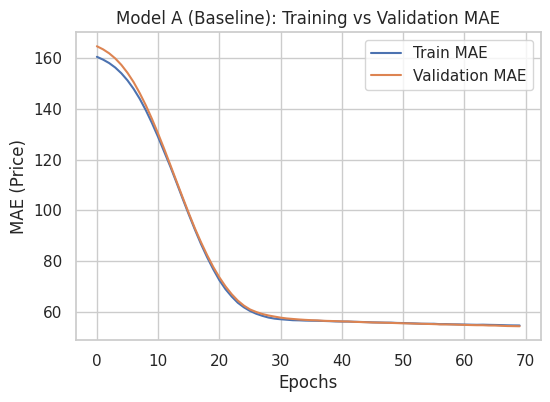

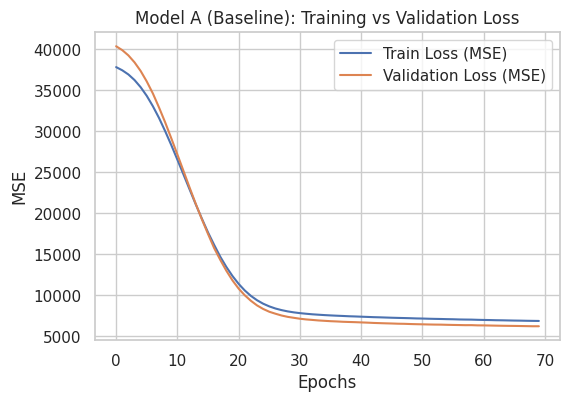

In [37]:

plot_training_curves(hist_a, model_name="Model A (Baseline)")

# uncomment lines below to generate plots for model_b and model_c

#plot_training_curves(hist_b, model_name="Model B (Deeper NN)")
#plot_training_curves(hist_c, model_name="Model C (Enhanced + EarlyStopping)")


In [38]:


print("Model A (Baseline)       -> MAE:", round(mae_a,2), " RMSE:", round(rmse_a,2), " R²:", round(r2_a,2))

# uncomment lines below to generate scores for model_b and model_c

#print("Model B (Deeper)         -> MAE:", round(mae_b,2), " RMSE:", round(rmse_b,2), " R²:", round(r2_b,2))
#print("Model C (Enhanced + ES)  -> MAE:", round(mae_c,2), " RMSE:", round(rmse_c,2), " R²:", round(r2_c,2))

Model A (Baseline)       -> MAE: 57.55  RMSE: 84.52  R²: 0.47
